<a href="https://colab.research.google.com/github/ga642381/ML2021-Spring/blob/main/HW06/HW06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **作业 6 - 生成对抗网络 (GAN)**

这是李宏毅老师机器学习课程作业 6 的示例代码。

本次作业要求构建一个生成对抗网络，用于动漫人脸生成。

## 环境配置

### 工作目录

In [12]:
# 如需更换工作目录，可在此修改
workspace_dir = "."

### 导入依赖包

In [13]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch import optim
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader

from qqdm.notebook import qqdm

### 数据集
https://www.kaggle.com/datasets/jonescrystal/crypko

In [14]:
# !unzip './crypko.zip'

### 解压下载的文件
解压后的目录结构如下：
```
faces/
├── 1.jpg
├── 2.jpg
├── 3.jpg
...
```

## 随机种子
设置随机种子为固定值，确保实验可复现。

In [15]:
def same_seeds(seed):
    # Python 内置随机模块
    random.seed(seed)
    # Numpy
    np.random.seed(seed)
    # Torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


same_seeds(2026)

## 数据集
1. 将图像缩放至 (64, 64)
2. 将像素值从 [0, 1] 线性映射到 [-1, 1]

各种 transform 的详细说明请参考 [PyTorch 官方文档](https://pytorch.org/vision/stable/transforms.html)。

In [16]:
class CrypkoDataset(Dataset):
    def __init__(self, fnames, transform):
        self.transform = transform
        self.fnames = fnames
        self.num_samples = len(self.fnames)

    def __getitem__(self, idx):
        fname = self.fnames[idx]
        # 1. 加载图像
        img = torchvision.io.read_image(fname)
        # 2. 使用 torchvision 缩放并归一化图像
        img = self.transform(img)
        return img

    def __len__(self):
        return self.num_samples


def get_dataset(root):
    fnames = glob.glob(os.path.join(root, "*"))
    # 1. 将图像缩放至 (64, 64)
    # 2. 将 [0, 1] 线性映射到 [-1, 1]
    compose = [
        transforms.ToPILImage(),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
    transform = transforms.Compose(compose)
    dataset = CrypkoDataset(fnames, transform)
    return dataset

### 展示部分图像
注意：当前像素值范围为 [-1, 1]，需要将其平移至有效范围 [0, 1] 才能正确显示。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


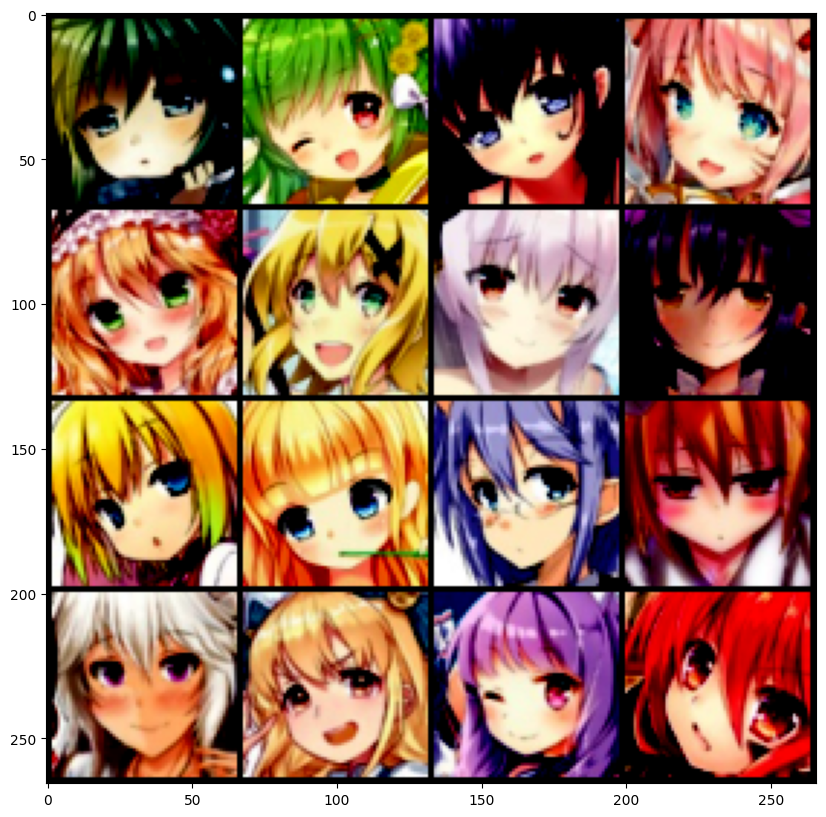

In [17]:
dataset = get_dataset(os.path.join(workspace_dir, "faces"))

images = [dataset[i] for i in range(16)]
grid_img = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

[-1,1] 反向映射到 [0,1] 是通过 $\frac{x + 1}{2}$ 得到

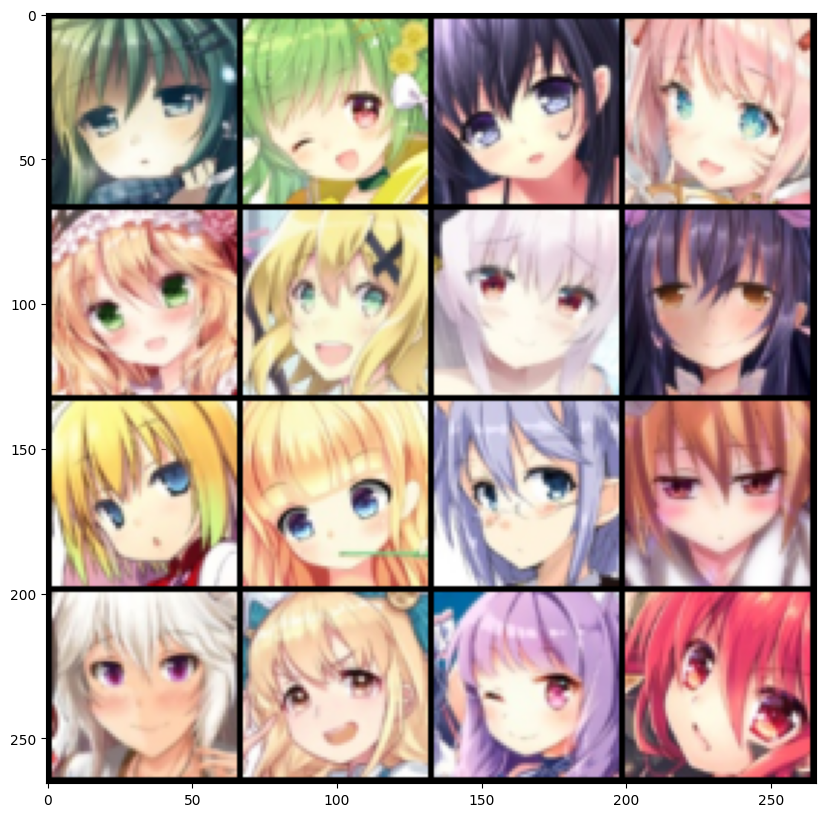

In [18]:
images = [(dataset[i] + 1) / 2 for i in range(16)]
grid_img = torchvision.utils.make_grid(images, nrow=4)
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

## 模型
这里使用 DCGAN (Deep Convolutional Generative Adversarial Network) 作为模型结构，可以自由修改模型结构。

注意：输入/输出形状中的 `N` 代表 batch size。

In [19]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)


class Generator(nn.Module):
    """
    Input shape: (N, in_dim)
    Output shape: (N, 3, 64, 64)
    """

    def __init__(self, in_dim, dim=64):
        super(Generator, self).__init__()

        def dconv_bn_relu(in_dim, out_dim):
            return nn.Sequential(
                nn.ConvTranspose2d(
                    in_dim, out_dim, 5, 2, padding=2, output_padding=1, bias=False
                ),
                nn.BatchNorm2d(out_dim),
                nn.ReLU(),
            )

        self.l1 = nn.Sequential(
            nn.Linear(in_dim, dim * 8 * 4 * 4, bias=False),
            nn.BatchNorm1d(dim * 8 * 4 * 4),
            nn.ReLU(),
        )
        self.l2_5 = nn.Sequential(
            dconv_bn_relu(dim * 8, dim * 4),
            dconv_bn_relu(dim * 4, dim * 2),
            dconv_bn_relu(dim * 2, dim),
            nn.ConvTranspose2d(dim, 3, 5, 2, padding=2, output_padding=1),
            nn.Tanh(),
        )
        self.apply(weights_init)

    def forward(self, x):
        y = self.l1(x)
        y = y.view(y.size(0), -1, 4, 4)
        y = self.l2_5(y)
        return y


class Discriminator(nn.Module):
    """
    Input shape: (N, 3, 64, 64)
    Output shape: (N, )
    """

    def __init__(self, in_dim, dim=64):
        super(Discriminator, self).__init__()

        def conv_bn_lrelu(in_dim, out_dim):
            return nn.Sequential(
                nn.Conv2d(in_dim, out_dim, 5, 2, 2),
                nn.BatchNorm2d(out_dim),
                nn.LeakyReLU(0.2),
            )

        """ 进阶: 使用 WGAN 时移除最后的 Sigmoid 层 """
        self.ls = nn.Sequential(
            nn.Conv2d(in_dim, dim, 5, 2, 2),
            nn.LeakyReLU(0.2),
            conv_bn_lrelu(dim, dim * 2),
            conv_bn_lrelu(dim * 2, dim * 4),
            conv_bn_lrelu(dim * 4, dim * 8),
            nn.Conv2d(dim * 8, 1, 4),
            nn.Sigmoid(),
        )
        self.apply(weights_init)

    def forward(self, x):
        y = self.ls(x)
        y = y.view(-1)
        return y

## 训练

### 初始化
- 超参数
- 模型
- 优化器
- 数据加载器

In [ ]:
# 训练超参数
batch_size = 64
z_dim = 100
z_sample = Variable(torch.randn(100, z_dim)).cuda()
lr = 1e-4

""" 进阶: WGAN, 50 epoch, n_critic=5, clip_value=0.01 """
n_epoch = 1  # 50
n_critic = 1  # 5
# clip_value = 0.01

log_dir = os.path.join(workspace_dir, "logs")
ckpt_dir = os.path.join(workspace_dir, "checkpoints")
os.makedirs(log_dir, exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

# 模型
G = Generator(in_dim=z_dim).cuda()
D = Discriminator(3).cuda()
G.train()
D.train()

# 损失函数
criterion = nn.BCELoss()

""" 进阶: WGAN 使用 RMSprop """
# 优化器
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
# opt_D = torch.optim.RMSprop(D.parameters(), lr=lr)
# opt_G = torch.optim.RMSprop(G.parameters(), lr=lr)


# 数据加载器
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

AssertionError: Torch not compiled with CUDA enabled

### 训练循环
定期保存部分生成图像，用于监控生成器的当前表现，并定期记录模型检查点。

   Iters      Elapsed Time      Speed    Loss_D  Loss_G  Epoch  Step            
 1115/1115  00:03:48<00:00:00  4.88it/s  0.6534  1.6622    1    1115            

IpythonBar(children=(HTML(value='  0.0%'), FloatProgress(value=0.0)))

 | Save some samples to ./logs/Epoch_001.jpg.


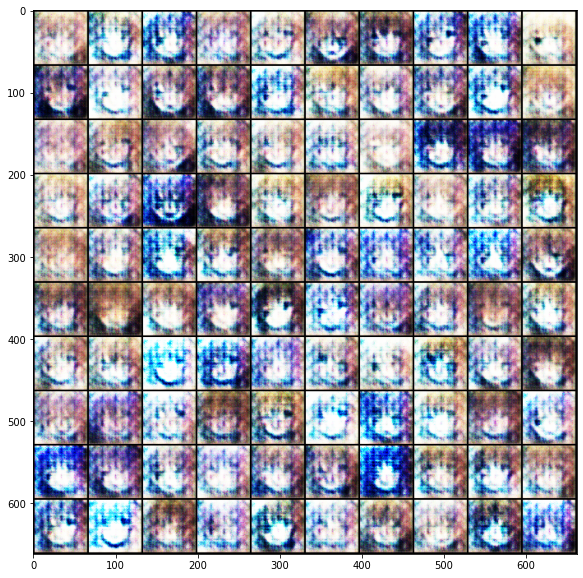

In [ ]:
steps = 0
for e, epoch in enumerate(range(n_epoch)):
    progress_bar = qqdm(dataloader)
    for i, data in enumerate(progress_bar):
        imgs = data
        imgs = imgs.cuda()

        bs = imgs.size(0)

        # ============================================
        #  训练判别器 D
        # ============================================
        z = Variable(torch.randn(bs, z_dim)).cuda()
        r_imgs = Variable(imgs).cuda()
        f_imgs = G(z)

        """ 进阶: 使用 WGAN 损失 """
        # 标签
        r_label = torch.ones((bs)).cuda()
        f_label = torch.zeros((bs)).cuda()

        # 前向传播
        r_logit = D(r_imgs.detach())
        f_logit = D(f_imgs.detach())

        # 计算判别器损失
        r_loss = criterion(r_logit, r_label)
        f_loss = criterion(f_logit, f_label)
        loss_D = (r_loss + f_loss) / 2

        # WGAN 损失
        # loss_D = -torch.mean(D(r_imgs)) + torch.mean(D(f_imgs))

        # 反向传播
        D.zero_grad()
        loss_D.backward()

        # 更新判别器
        opt_D.step()

        """ 进阶: 裁剪判别器权重 """
        # for p in D.parameters():
        #    p.data.clamp_(-clip_value, clip_value)

        # ============================================
        #  训练生成器 G
        # ============================================
        if steps % n_critic == 0:
            # 生成一些假图像
            z = Variable(torch.randn(bs, z_dim)).cuda()
            f_imgs = G(z)

            # 前向传播
            f_logit = D(f_imgs)

            """ 进阶: 使用 WGAN 损失"""
            # 计算生成器损失
            loss_G = criterion(f_logit, r_label)
            # WGAN 损失
            # loss_G = -torch.mean(D(f_imgs))

            # 反向传播
            G.zero_grad()
            loss_G.backward()

            # 更新生成器
            opt_G.step()

        steps += 1

        # 设置进度条信息
        #   注意：GAN 损失值与生成图像质量没有直接关系
        progress_bar.set_infos(
            {
                "Loss_D": round(loss_D.item(), 4),
                "Loss_G": round(loss_G.item(), 4),
                "Epoch": e + 1,
                "Step": steps,
            }
        )

    G.eval()
    f_imgs_sample = (G(z_sample).data + 1) / 2.0
    filename = os.path.join(log_dir, f"Epoch_{epoch+1:03d}.jpg")
    torchvision.utils.save_image(f_imgs_sample, filename, nrow=10)
    print(f" | 保存部分样本到 {filename}.")

    # 在 notebook 中展示生成的图像
    grid_img = torchvision.utils.make_grid(f_imgs_sample.cpu(), nrow=10)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.show()
    G.train()

    if (e + 1) % 5 == 0 or e == 0:
        # 保存模型检查点
        torch.save(G.state_dict(), os.path.join(ckpt_dir, "G.pth"))
        torch.save(D.state_dict(), os.path.join(ckpt_dir, "D.pth"))

## 推理
使用训练好的模型生成动漫人脸！

### 加载模型

In [ ]:
G = Generator(z_dim)
G.load_state_dict(torch.load(os.path.join(ckpt_dir, "G.pth")))
G.eval()
G.cuda()

Generator(
  (l1): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=False)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (l2_5): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (1): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
    )
    (2): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()


### 生成并展示部分图像

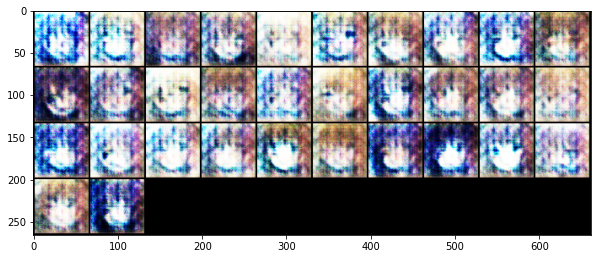

In [ ]:
# 生成 1000 张图像并拼接成网格保存
n_output = 1000
z_sample = Variable(torch.randn(n_output, z_dim)).cuda()
imgs_sample = (G(z_sample).data + 1) / 2.0
log_dir = os.path.join(workspace_dir, "logs")
filename = os.path.join(log_dir, "result.jpg")
torchvision.utils.save_image(imgs_sample, filename, nrow=10)

# 展示其中 32 张
grid_img = torchvision.utils.make_grid(imgs_sample[:32].cpu(), nrow=10)
plt.figure(figsize=(10, 10))
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

### 使用 **tar** 压缩生成的图像

In [ ]:
# 保存生成的图像
os.makedirs('output', exist_ok=True)
for i in range(1000):
    torchvision.utils.save_image(imgs_sample[i], f'output/{i+1}.jpg')
  
# 压缩图像
%cd output
!tar -zcf ../images.tgz *.jpg
%cd ..

/content/output
/content
